In this notebook, we aim to produce scatterplots for analyzing the correlation between two datsets.

In [1]:
from geostat_isoscapes_tools import geostat_utils,utils, plot_utils, sisal_utils
import seaborn as sns
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
from scipy.stats import pearsonr
from scipy import odr
import rasterio
from rasterio.transform import xy
from tqdm import tqdm
import json 

sns.set_theme(
    style="ticks",
    context="talk",
    font_scale=0.9,
    palette='colorblind'
)

def linear_model(B, x):
    return B[0]*x+B[1]

## Correlation of SISAL and iTrace data points

If saved csv is not available :

In [2]:
# import sisal data 
sisal_df = geostat_utils.get_sisal_data_for_kriging(res=1,temp_ds_name='itrace',temp_ds_path='/media/luluxette/T7_Shield/pdm/iTrace/',regions=None,verbose=False) # res=1 year
# import itrace data
with open(f'{utils.get_project_root()}/data/iTrace_simulations_dict.json', 'r') as f:
    itrace_sims = json.load(f)

list_df = []
for t,t_dict in itrace_sims.items(): # takes a while...
    if t!='_comment':
        itrace_df = geostat_utils.get_preprocessed_itrace_data(data_folder='/media/luluxette/T7_Shield/pdm/iTrace/',res=12,sim_kyr=t_dict['yrBPname'],sim_num=t_dict['num'],sim_suffix=t_dict['suffix'],sim_forcings=t_dict['forcings'],format='df',verbose=False) # res=12months=1yr
        itrace_df['age_yrBP']=utils.get_yrBP_from_itrace_time(np.asarray(itrace_df['time']),int(t)*1000) #type:ignore
        itrace_df = itrace_df[['age_yrBP','lat','lon','d18Op']] #type:ignore
        list_df.append(itrace_df)
itrace_df = pd.concat(list_df)


converting speleothem data to drip-water equivalents...


KeyboardInterrupt: 

In [11]:
itrace_df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Index: 56373582 entries, 0 to 13809736
Data columns (total 4 columns):
 #   Column    Dtype  
---  ------    -----  
 0   lat       float32
 1   lon       float32
 2   d18Op     float32
 3   age_yrBP  float64
dtypes: float32(3), float64(1)
memory usage: 1.5 GB


In [12]:
itrace_df.to_csv('/media/luluxette/T7_Shield/pdm/itrace_df_20ka_11ka_res12months.csv')
sisal_df.to_csv('/media/luluxette/T7_Shield/pdm/sisal_df_20ka_11ka_res12months.csv')

If already saved the csv file :

In [2]:
itrace_df = pd.read_csv('/media/luluxette/T7_Shield/pdm/itrace_df_20ka_11ka_res12months.csv')
sisal_df = pd.read_csv('/media/luluxette/T7_Shield/pdm/sisal_df_20ka_11ka_res12months.csv')

In [4]:
# take only the points that share same loc (radius around sisal = x km) and time (yearly resolution), put them by pairs in a new dataframe
# 1. mask iTrace data to keep only points around sisal locs 
rad = 200
itrace_df_masked,_ = utils.mask_union_of_circles_around_pts(itrace_df,sisal_df[['lat','lon']],radius_km=rad) # type:ignore

In [7]:
# 2. For each sisal point find the closest itrace point in space and time (same year and less than x km away), and store them as a pair in a new dataframe
paired_data=[]
dist_max = 200
for idx, sisal_row in sisal_df.iterrows():
    sisal_loc = (sisal_row['lat'],sisal_row['lon'])
    sisal_site_name = sisal_row['site_name']
    sisal_age = sisal_row['age']
    itrace_candidates = itrace_df_masked[itrace_df_masked['age_yrBP']==sisal_age].copy()
    if len(itrace_candidates)==0:
        continue
    # find the closest itrace canditate
    itrace_candidates['dist_km'] = itrace_candidates.apply(lambda row : utils.haversine(sisal_loc,(row.lat,row.lon)), axis=1)
    closest_itrace = itrace_candidates.loc[itrace_candidates['dist_km'].idxmin()]
    if closest_itrace['dist_km']>dist_max:
        continue
        # print(f"skipping cave {sisal_site_name}, closest neighbourgh is too far away ({closest_itrace['dist_km']})")
    paired_data.append({'age':sisal_age,
                        'site':sisal_site_name,
                        'sisal_d18Op':sisal_row['d18Op_VSMOW_exactconv'],
                        'sisal_d18Oc': sisal_row['d18O_measurement'],
                        'itrace_d18Op':closest_itrace['d18Op'],
                        'sisal_lat':sisal_row['lat'],
                        'sisal_lon':sisal_row['lon'],
                        'itrace_lat':closest_itrace['lat'],
                        'itrace_lon':closest_itrace['lon'],
                        'dist_km':closest_itrace['dist_km']})
paired_df = pd.DataFrame(paired_data)

In [10]:
paired_df[paired_df.site == 'Devils Hole']

,age,site,sisal_d18Op,sisal_d18Oc,itrace_d18Op,sisal_lat,sisal_lon,itrace_lat,itrace_lon,dist_km
5811,11555.0,Devils Hole,-17.817538,-16.50,-12.767851,36.4254,-116.2915,36.94737,-117.5,122.395847
5812,12242.0,Devils Hole,-19.506681,-16.54,-11.959494,36.4254,-116.2915,36.94737,-117.5,122.395847
5813,12929.0,Devils Hole,-18.353018,-16.50,-11.402488,36.4254,-116.2915,36.94737,-117.5,122.395847
5814,13634.0,Devils Hole,-18.465962,-16.51,-11.573702,36.4254,-116.2915,36.94737,-117.5,122.395847
5815,14340.0,Devils Hole,-18.476414,-16.39,-12.258202,36.4254,-116.2915,36.94737,-117.5,122.395847
5816,15751.0,Devils Hole,-19.107148,-16.40,-11.398822,36.4254,-116.2915,36.94737,-117.5,122.395847
5817,17162.0,Devils Hole,-19.844291,-16.47,-11.451929,36.4254,-116.2915,36.94737,-117.5,122.395847
5818,18573.0,Devils Hole,-19.039974,-16.46,-11.376679,36.4254,-116.2915,36.94737,-117.5,122.395847
5819,19984.0,Devils Hole,-19.116182,-16.51,-11.992634,36.4254,-116.2915,36.94737,-117.5,122.395847
5820,11159.0,Devils Hole,-17.469812,-16.01,-10.903865,36.4254,-116.2915,36.94737,-117.5,122.395847


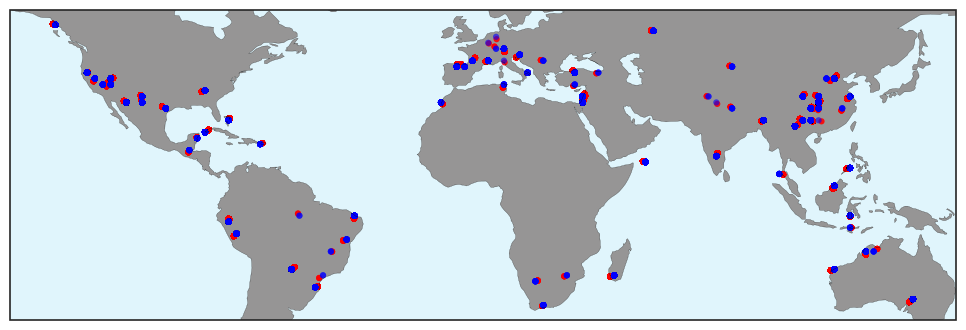

In [11]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

sns.set_theme(context='talk',
                style='ticks',
                palette='colorblind',
                rc={'axes.linewidth':1.2,"grid.alpha":0.3,"grid.linestyle":'--'})

fig, ax = plt.subplots(figsize=(10,5),
                        subplot_kw={"projection": ccrs.PlateCarree()})

# Scatter plot of irregular points
ax.scatter(
    paired_df['sisal_lon'],
    paired_df['sisal_lat'],
    transform=ccrs.PlateCarree(),
    s=20,
    color='red',
    edgecolor="none",
    alpha=0.9,
)

ax.scatter(
    paired_df['itrace_lon'],
    paired_df['itrace_lat'],
    transform=ccrs.PlateCarree(),
    s=20,
    color='blue',
    edgecolor="none",
    alpha=0.6,
)


# ax.coastlines() # type:ignore
ax.add_feature(cfeature.COASTLINE, linewidth=0.2) #type:ignore
ax.add_feature(cfeature.LAND, facecolor="#969595", edgecolor="none")#type:ignore
ax.add_feature(cfeature.OCEAN, facecolor="#e0f5fc", edgecolor="none")#type:ignore

plt.tight_layout()
plt.show()

In [12]:
paired_df = sisal_utils.retrieve_continent_from_lat_lon(paired_df,lat_col='sisal_lat',lon_col='sisal_lon')
paired_df['color']=''
colors_continents = {'Asia': "#7d0303",
                     'North America': "#03838f",
                     'South America':  "#100a78",
                     'Middle East': "#244a1f",
                     'Europe': "#72b45e",
                     'Oceania': "#4A1178",
                     'Indonesia': "#f6c207",
                     'Africa' : "#a93b95"
                     }
for continent,color in colors_continents.items():
    paired_df.loc[paired_df['continent']==continent,'color']=color

In [13]:
paired_df['ratio']=np.clip(np.log(paired_df['itrace_d18Op']/paired_df['sisal_d18Op']),-2,2)  # logbias : ln(s/i) si s>i -> positive (overestimation), si s<i -> negative : underestimation
plot_utils.plot_global_map(paired_df,title='ratio ln(itrace_d18Op/sisal_d18Op)',
                           quantity_col='ratio',
                           quantity='d18Op_itrace/d18Op_sisal',
                           unit='',
                           lon_col='sisal_lon',
                           lat_col='sisal_lat',
                           colorscale='RdBu',
                           landcolor="#3a5540",
                           symbol='circle')

In [14]:
len(sisal_df.site_name.unique())

135

In [15]:
paired_df[paired_df['site'].isin(['Pink Panther cave','Sofular cave'])]

,age,site,sisal_d18Op,sisal_d18Oc,itrace_d18Op,sisal_lat,sisal_lon,itrace_lat,itrace_lon,dist_km,continent,color,ratio
5092,11101.0,Sofular cave,-12.264435,-10.92,-9.385615,41.4167,31.9333,40.736843,32.5,89.281547,Europe,#72b45e,-0.267525
5093,11208.0,Sofular cave,-12.467439,-11.22,-8.769006,41.4167,31.9333,40.736843,32.5,89.281547,Europe,#72b45e,-0.351897
5094,11315.0,Sofular cave,-12.873262,-11.12,-9.243131,41.4167,31.9333,40.736843,32.5,89.281547,Europe,#72b45e,-0.331272
5095,11696.0,Sofular cave,-13.804015,-11.69,-9.234726,41.4167,31.9333,40.736843,32.5,89.281547,Europe,#72b45e,-0.401989
5096,11832.0,Sofular cave,-13.994640,-12.06,-9.660452,41.4167,31.9333,40.736843,32.5,89.281547,Europe,#72b45e,-0.370634
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10526,17180.0,Sofular cave,-14.727163,-11.88,-8.223862,41.4167,31.9333,40.736843,32.5,89.281547,Europe,#72b45e,-0.582654
10527,17790.0,Sofular cave,-14.259408,-11.55,-7.788062,41.4167,31.9333,40.736843,32.5,89.281547,Europe,#72b45e,-0.604825
10528,18400.0,Sofular cave,-13.683118,-11.45,-8.692265,41.4167,31.9333,40.736843,32.5,89.281547,Europe,#72b45e,-0.453729
10529,19010.0,Sofular cave,-13.732926,-11.28,-9.193689,41.4167,31.9333,40.736843,32.5,89.281547,Europe,#72b45e,-0.401279


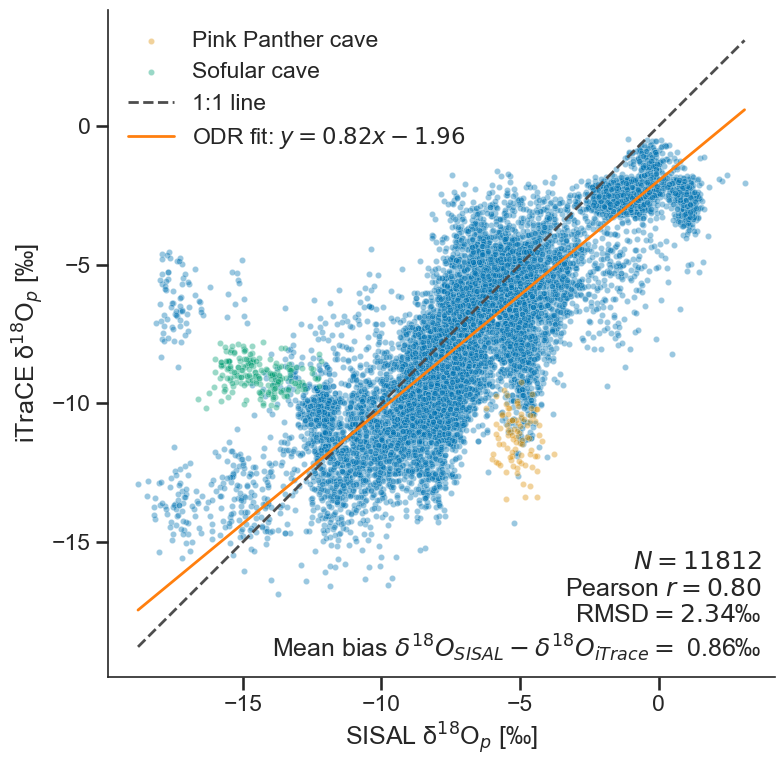

In [19]:
paired_df['site_pb']=False
paired_df.loc[paired_df.site.isin(['Pink Panther cave','Sofular cave','Devils Hole']),'site_pb']=True # Kesang cave, Sofular cave

df = paired_df[~paired_df.site.isin(['Pink Panther cave','Sofular cave','Devils Hole'])]#[paired_df['continent'].isin(['Asia','North America'])]
df_ppc = paired_df[paired_df.site == 'Pink Panther cave']
df_sc = paired_df[paired_df.site == 'Sofular cave']

x = 'sisal_d18Op'
y = 'itrace_d18Op'

# metrics
r, p_value = pearsonr(df[x], df[y])
rmse = utils.RMSE(df[x], df[y])
bias = np.mean(df[x]-df[y])

fig, ax = plt.subplots(figsize=(10,8))

sns.scatterplot(data=df,x=x,y=y,s=20,alpha=0.4,ax=ax) #hue='continent',palette=colors_continents,edgecolor="white",linewidth=0.5
sns.scatterplot(data=df_ppc,x=x,y=y,s=20,alpha=0.4,ax=ax,label='Pink Panther cave') #hue='continent',palette=colors_continents,edgecolor="white",linewidth=0.5
sns.scatterplot(data=df_sc,x=x,y=y,s=20,alpha=0.4,ax=ax,label='Sofular cave') #hue='continent',palette=colors_continents,edgecolor="white",linewidth=0.5

# 1:1 line
min_val = min(df[x].min(),df[y].min())
max_val = max(df[x].max(),df[y].max())
ax.plot([min_val, max_val],[min_val, max_val],linestyle="--",linewidth=2,color="0.3",label="1:1 line")

# Linear fit
model = odr.Model(linear_model)
data = odr.Data(paired_df[x], paired_df[y])
odr_fit = odr.ODR(data, model, beta0=[1, 0])
out = odr_fit.run()
slope, intercept = out.beta
x_vals = np.linspace(min_val, max_val, 200)
y_vals = intercept + slope * x_vals
ax.plot(x_vals,y_vals,linewidth=2,label=fr'ODR fit: $y={slope:.2f}x {intercept:+.2f}$',color='tab:orange')

ax.text(0.98,0.02,
    fr'$N = {len(paired_df)}$' '\n'
    fr'Pearson $r={r:.2f}$' '\n'
    # fr'Pearson $r$ p-value $p={p_value :.2E}$' '\n'
    fr'RMSD$={rmse:.2f}$‰' '\n'
    r'Mean bias $\delta^{18}O_{SISAL}-\delta^{18}O_{iTrace}=$' f'{bias : .2f}‰',
    transform=ax.transAxes, va='bottom',ha='right',
    bbox=dict(boxstyle="round",facecolor="white",edgecolor="0.85",alpha=0.))

# Labels
ax.set_xlabel('SISAL δ$^{18}$O$_p$ [‰]')
ax.set_ylabel('iTraCE δ$^{18}$O$_p$ [‰]')
# ax.set_title('SISAL versus iTrace δ$^{18}$O$_p$', pad=10)

# Final styling
sns.despine(ax=ax)
ax.legend(frameon=False)
ax.set_aspect('equal', adjustable='box')

fig.tight_layout()
# plt.savefig('../output/data_exploration/correlation_scatterplot_itrace_sisal_max80km.png',dpi=500)
plt.show()

## Correlation between RCWIP and SISAL data

In [2]:
sisal_df = geostat_utils.get_sisal_data_for_kriging(res=None, regions=None, conversion=None)
sisal_df=sisal_df[sisal_df['age'].between(-66,-10)] # rcwip covers 1950-2016 = "-10"yrBP to "-66"yrBP
sisal_df = sisal_df[['lat','lon','d18O_measurement','site_id']].groupby('site_id').mean()
pairs_df_list = []
for lon in [150,120,90,60,30,0,-30,-60,-90,-120,-150,-180]:
    if lon<0:
        lo = f'W{-lon}'
    else : 
        lo = f'E{lon}'
    for lat in [60,30,0,-30,-60]:
        if lat<0:
            la = f'S{-lat}'
        else : 
            la = f'N{lat}'
        
        print('=============',lo,la,'===============')
        print(f'searching lat between {lat},{lat+30} and lon between {lon},{lon+30}')
        sisal_subdf = sisal_df[sisal_df['lat'].between(lat,lat+30) & sisal_df['lon'].between(lon,lon+30)].copy()
        if len(sisal_subdf)==0:
            print('no sisal data in this area')
            continue
        try :
            with rasterio.open(f'../data/modern/RCWIP2_isoscape/O18_{lo}_{la}_13.tif') as f:
                rcwip_data = f.read(1)
                transform = f.transform
                crs = f.crs
                nodata= f.nodata
        except Exception as e :
            print(e)
            continue

        # compute coordinates 
        rows, cols = np.meshgrid(
            np.arange(rcwip_data.shape[0]),
            np.arange(rcwip_data.shape[1]),
            indexing="ij"
        )
        xs, ys = xy(transform, rows, cols, offset="center")
        xs = np.array(xs)
        ys = np.array(ys)

        # get valid pixels
        values = rcwip_data.ravel()
        mask = np.ones(values.shape, dtype=bool)
        mask &= np.abs(values)<10e3
        mask &= ~np.isnan(values)

        # convert to dataframe
        rcwip_df = pd.DataFrame({
            "lon": xs[mask],
            "lat": ys[mask],
            "value": values[mask]
        })
        
        paired_data=[]
        rad = 100
        for idx, sisal_row in tqdm(sisal_subdf.groupby('site_id')):
            sisal_loc = (sisal_row['lat'].values[0],sisal_row['lon'].values[0])
            # find the closest rcwip point. Easy since it has a regular grid
            rcwip_df['dlat']=np.abs(rcwip_df['lat']-sisal_loc[0])
            rcwip_df['dlon']=np.abs(rcwip_df['lon']-sisal_loc[1])
            min_lon = rcwip_df.loc[rcwip_df['dlon'].idxmin(),'lon']
            min_lat = rcwip_df.loc[rcwip_df['dlat'].idxmin(),'lat']
            closest_rcwip = rcwip_df[(rcwip_df['lon']==min_lon)&(rcwip_df['lat']==min_lat)]
            
            if len(closest_rcwip)==0: # in case the optimal grid point is not valid (removed earlier from rcwip data)
                print('missing data - computing distances...')
                eps=0.5
                i=0.5
                while len(closest_rcwip)<1:
                    eps += i
                    rcwip_subdf = rcwip_df[rcwip_df['lon'].between(sisal_loc[1]-eps,sisal_loc[1]+eps)
                                        & rcwip_df['lat'].between(sisal_loc[0]-eps,sisal_loc[0]+eps)].copy()
                    print(rcwip_subdf)
                    rcwip_subdf['dist_km'] = rcwip_subdf.apply(lambda row : utils.haversine(sisal_loc,(row.lat,row.lon)), axis=1)
                    candidate = rcwip_subdf.iloc[rcwip_subdf['dist_km'].idxmin()]
                    if candidate['dist_km']>rad:
                        print('found closest point at', closest_rcwip['dist_km'],'km -> too far away')
                    else : 
                        closest_rcwip = candidate
                        print('found closest point at', closest_rcwip['dist_km'],'km')
            
            paired_data.append({'sisal_d18Oc':sisal_row['d18O_measurement'].values[0],
                                'rcwip_d18Op':closest_rcwip['value'].values[0],
                                'sisal_lat':sisal_row['lat'].values[0],
                                'sisal_lon':sisal_row['lon'].values[0],
                                'rcwip_lat':closest_rcwip['lat'].values[0],
                                'rcwip_lon':closest_rcwip['lon'].values[0],
                                })
        pairs_df_list.append(pd.DataFrame(paired_data))

pairs_df = pd.concat(pairs_df_list)

loading sisal data
-> loading SISAL database
   cleaning samples
loading and cleaning done.
sisal dataframe is ready
============= E150 N60 ===============
searching lat between 60,90 and lon between 150,180
no sisal data in this area
============= E150 N30 ===============
searching lat between 30,60 and lon between 150,180
no sisal data in this area
============= E150 N0 ===============
searching lat between 0,30 and lon between 150,180
no sisal data in this area
============= E150 S30 ===============
searching lat between -30,0 and lon between 150,180


100%|██████████| 2/2 [00:00<00:00, 142.76it/s]


============= E150 S60 ===============
searching lat between -60,-30 and lon between 150,180


100%|██████████| 3/3 [00:00<00:00, 171.41it/s]


============= E120 N60 ===============
searching lat between 60,90 and lon between 120,150
no sisal data in this area
============= E120 N30 ===============
searching lat between 30,60 and lon between 120,150


...

============= W90 S60 ===============
searching lat between -60,-30 and lon between -90,-60
no sisal data in this area
============= W120 N60 ===============
searching lat between 60,90 and lon between -120,-90
no sisal data in this area
============= W120 N30 ===============
searching lat between 30,60 and lon between -120,-90


100%|██████████| 5/5 [00:00<00:00,  7.03it/s]


============= W120 N0 ===============
searching lat between 0,30 and lon between -120,-90


100%|██████████| 1/1 [00:00<00:00, 46.39it/s]

============= W120 S30 ===============
searching lat between -30,0 and lon between -120,-90
no sisal data in this area
============= W120 S60 ===============
searching lat between -60,-30 and lon between -120,-90
no sisal data in this area
============= W150 N60 ===============
searching lat between 60,90 and lon between -150,-120
no sisal data in this area
============= W150 N30 ===============
searching lat between 30,60 and lon between -150,-120
no sisal data in this area
============= W150 N0 ===============
searching lat between 0,30 and lon between -150,-120
no sisal data in this area
============= W150 S30 ===============
searching lat between -30,0 and lon between -150,-120
no sisal data in this area
============= W150 S60 ===============
searching lat between -60,-30 and lon between -150,-120
no sisal data in this area
============= W180 N60 ===============
searching lat between 60,90 and lon between -180,-150
no sisal data in this area
============= W180 N30 ===============
s

In [3]:
len(pairs_df)

114

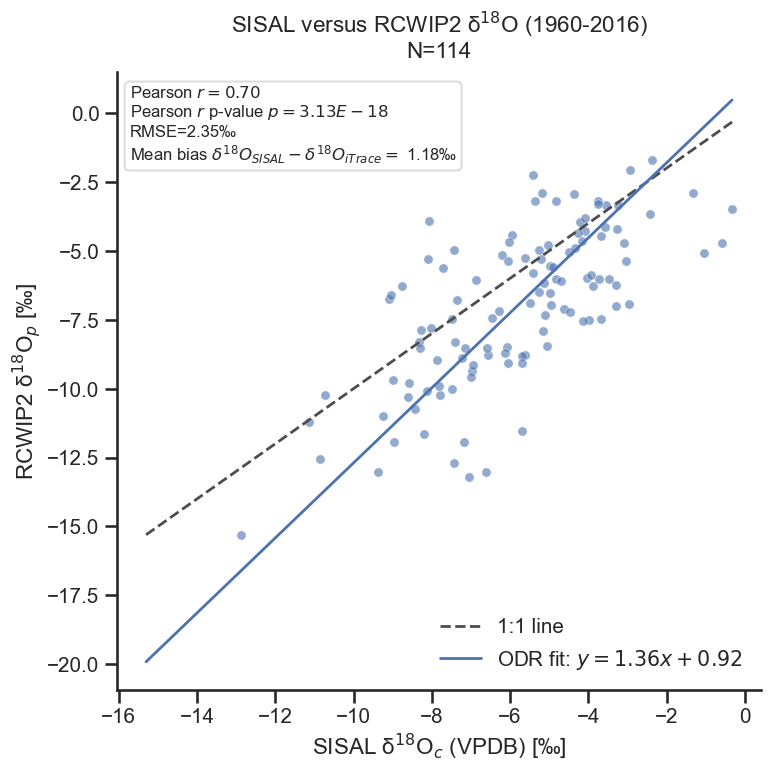

In [4]:
x = 'sisal_d18Oc'
y = 'rcwip_d18Op'

# metrics
r, p_value = pearsonr(pairs_df[x], pairs_df[y])
rmse = utils.RMSE(pairs_df[x], pairs_df[y])
bias = np.mean(pairs_df[x]-pairs_df[y])

# plot
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(data=pairs_df,x=x,y=y,s=45,alpha=0.6,edgecolor="white",linewidth=0.5,ax=ax)

# 1:1 line
min_val = min(pairs_df[x].min(),pairs_df[y].min())
max_val = max(pairs_df[x].max(),pairs_df[y].max())
ax.plot( [min_val, max_val], [min_val, max_val],linestyle="--",linewidth=2,color="0.3",label="1:1 line")

# Linear fit # this is a wrong method since it assumes that x has no error!
# slope, intercept = np.polyfit(pairs_df[x], pairs_df[y],1)
# y_vals = intercept + slope * x_vals
# ax.plot(x_vals,y_vals,linewidth=2,label=fr'OLS fit: $y={slope:.2f}x {intercept:+.2f}$')
# Orthogonal regression
model = odr.Model(linear_model)
data = odr.Data(pairs_df[x], pairs_df[y])
odr_fit = odr.ODR(data, model, beta0=[1, 0])
out = odr_fit.run()
slope, intercept = out.beta
x_vals = np.linspace(min_val, max_val, 200)
y_vals = intercept + slope * x_vals

ax.plot(x_vals,y_vals,linewidth=2,label=fr'ODR fit: $y={slope:.2f}x {intercept:+.2f}$')

ax.text(0.02,0.98,
    fr'Pearson $r={r:.2f}$' '\n'
    fr'Pearson $r$ p-value $p={p_value :.2E}$' '\n'
    fr'RMSE={rmse:.2f}‰' '\n'
    r'Mean bias $\delta^{18}O_{SISAL}-\delta^{18}O_{iTrace}=$' f'{bias : .2f}‰',
    transform=ax.transAxes, va='top',ha='left',fontsize=12,
    bbox=dict(boxstyle="round",facecolor="white",edgecolor="0.85",alpha=0.9))

ax.set_xlabel('SISAL δ$^{18}$O$_c$ (VPDB) [‰]')
ax.set_ylabel('RCWIP2 δ$^{18}$O$_p$ [‰]')
ax.set_title('SISAL versus RCWIP2 δ$^{18}$O (1960-2016)' '\n' 'N=114', pad=10)
sns.despine(ax=ax)
ax.legend(frameon=False)
# ax.set_aspect('equal', adjustable='box')

fig.tight_layout()
# plt.savefig('../output/correlation_scatterplot_rcwip_sisal.png',dpi=300)
plt.show()


In [48]:
pairs_df['ratio']=np.log(pairs_df['rcwip_d18Op']/pairs_df['sisal_d18Oc'])  # logbias : ln(s/i) si s>i -> positive (overestimation), si s<i -> negative : underestimation
plot_utils.plot_global_map(pairs_df,title='ln(rcwip_d18Op/sisal_d18Oc)',
                           quantity_col='ratio',
                           quantity='d18Op_rcwip/d18Oc_sisal',
                           unit='',
                           lon_col='sisal_lon',
                           lat_col='sisal_lat',
                           colorscale='RdBu',
                           landcolor="#3a5540",
                           symbol='circle')